# 02 - Baseline, Machine Learning, Boosting và Ablation Study 

Notebook này dùng đầu ra từ **Ngày 1**:

- `outputs/processed_morocco_hourly_features.csv`
- `outputs/feature_columns.csv`

và ghi toàn bộ kết quả Ngày 2 vào thư mục riêng:

- `outputs_02/`
- `figures_02/`
- `models_02/`

Mục tiêu Ngày 2:

1. Huấn luyện các baseline forecasting: Persistence, Seasonal Persistence.
2. Huấn luyện các mô hình nối với bài báo gốc: Linear/Ridge, Random Forest, SVR, MLP.
3. Huấn luyện mô hình ML hiện đại hơn: HistGradientBoosting, XGBoost và CatBoost.
4. Đánh giá bằng **all-hours metrics** và **daylight-only metrics**.
5. Tuning nhẹ HGBR theo validation daylight RMSE.
6. Ablation study để chứng minh tác dụng của time, lag, rolling, weather lag, physical/pvlib features.
7. Chỉ lưu những file CSV thật sự cần cho báo cáo.


In [1]:
# ============================================================
# 0. Imports, paths, config
# ============================================================

from __future__ import annotations

import os
import sys
import json
import time
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error
from sklearn.inspection import permutation_importance
import joblib

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
BASE_DIR = Path.cwd()

# Input từ notebook 01
INPUT_DIR = BASE_DIR / "outputs"

# Nếu chạy trong sandbox hoặc folder khác, fallback /mnt/data
if not (INPUT_DIR / "processed_morocco_hourly_features.csv").exists():
    BASE_DIR = Path("/mnt/data")
    INPUT_DIR = BASE_DIR / "outputs"

# Output riêng cho 02 để không lẫn với 01
OUT_DIR = BASE_DIR / "outputs_02"
FIG_DIR = BASE_DIR / "figures_02"
MODEL_DIR = BASE_DIR / "models_02"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = INPUT_DIR / "processed_morocco_hourly_features.csv"
FEATURE_PATH = INPUT_DIR / "feature_columns.csv"

# Chạy cả 1-hour ahead và 24-hour ahead.
# Nếu muốn chạy nhanh hơn: TARGETS_TO_RUN = ["target_1h"]
TARGETS_TO_RUN = ["target_1h", "target_24h"]
PRIMARY_TARGET = "target_1h"

print("Python executable:", sys.executable)
print("BASE_DIR:", BASE_DIR)
print("INPUT_DIR:", INPUT_DIR)
print("OUT_DIR:", OUT_DIR)
print("DATA_PATH exists:", DATA_PATH.exists())
print("FEATURE_PATH exists:", FEATURE_PATH.exists())

print("XGBoost and CatBoost imported successfully.")


Python executable: c:\Users\nguye\AppData\Local\Programs\Python\Python314\python.exe
BASE_DIR: c:\Users\nguye\Downloads\Big_Data
INPUT_DIR: c:\Users\nguye\Downloads\Big_Data\outputs
OUT_DIR: c:\Users\nguye\Downloads\Big_Data\outputs_02
DATA_PATH exists: True
FEATURE_PATH exists: True
XGBoost and CatBoost imported successfully.


## 1. Load dữ liệu đã xử lý 

Cell này kiểm tra dữ liệu, danh sách feature và tự loại các cột không an toàn/không có ý nghĩa như `target_1h`, `target_24h`, `pvlib_available`, các cột hằng số.

In [2]:
# ============================================================
# 1. Load processed data and feature columns
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy {DATA_PATH}. Hãy chạy notebook Ngày 1 trước.")

df = pd.read_csv(DATA_PATH)

# Tự nhận diện cột thời gian
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.set_index("datetime")
else:
    # Nếu file lưu index không tên
    first_col = df.columns[0]
    try:
        parsed = pd.to_datetime(df[first_col])
        if parsed.notna().mean() > 0.95:
            df[first_col] = parsed
            df = df.set_index(first_col)
            df.index.name = "datetime"
    except Exception:
        pass

df = df.sort_index()

if FEATURE_PATH.exists():
    feature_cols = pd.read_csv(FEATURE_PATH).iloc[:, 0].dropna().astype(str).tolist()
else:
    exclude_cols = ["YEAR", "MO", "DY", "HR", "target_1h", "target_24h"]
    feature_cols = [c for c in df.columns if c not in exclude_cols]

# Làm sạch danh sách feature
unsafe_cols = {"target_1h", "target_24h", "YEAR", "MO", "DY", "HR", "pvlib_available"}
feature_cols = [c for c in feature_cols if c in df.columns and c not in unsafe_cols]

# Chỉ giữ cột numeric
numeric_cols = set(df.select_dtypes(include=[np.number]).columns)
feature_cols = [c for c in feature_cols if c in numeric_cols]

# Loại cột hằng số
constant_cols = [c for c in feature_cols if df[c].nunique(dropna=False) <= 1]
feature_cols = [c for c in feature_cols if c not in constant_cols]

print("Data shape:", df.shape)
print("Date range:", df.index.min(), "→", df.index.max())
print("Number of cleaned feature columns:", len(feature_cols))
print("Removed constant cols:", constant_cols)
print("Targets available:", [c for c in ["target_1h", "target_24h"] if c in df.columns])

display(df.head())
display(pd.Series(feature_cols, name="feature").to_frame().head(20))

Data shape: (25944, 77)
Date range: 2016-01-15 00:00:00 → 2018-12-30 23:00:00
Number of cleaned feature columns: 67
Removed constant cols: []
Targets available: ['target_1h', 'target_24h']


,YEAR,MO,DY,HR,Pressure,Wind_Speed,Wind_Direction,Humidity,Solar_Radiation_Wh_m2,Temperature,...,pvlib_solar_elevation_deg,pvlib_solar_zenith_deg,pvlib_clear_sky_ghi_Wh_m2,pvlib_clear_sky_index_current,sim_cell_temperature_C,sim_pv_dc_kWh_per_kWp,sim_pv_ac_kWh_per_kWp,sim_pv_ac_lag_1h,sim_pv_ac_lag_24h,sim_pv_ac_lag_168h
datetime,,,,,,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,2016,1,15,0,87.59,2.58,312.0,35.68,0.0,6.87,...,-77.778787,167.778787,0.0,0.0,6.87,0.0,0.0,0.0,0.0,0.0
2016-01-15 01:00:00,2016,1,15,1,87.55,2.59,318.1,36.85,0.0,6.45,...,-77.001686,167.001686,0.0,0.0,6.45,0.0,0.0,0.0,0.0,0.0
2016-01-15 02:00:00,2016,1,15,2,87.51,2.62,321.0,38.12,0.0,6.01,...,-66.650803,156.650803,0.0,0.0,6.01,0.0,0.0,0.0,0.0,0.0
2016-01-15 03:00:00,2016,1,15,3,87.47,2.79,323.5,39.78,0.0,5.39,...,-54.326095,144.326095,0.0,0.0,5.39,0.0,0.0,0.0,0.0,0.0
2016-01-15 04:00:00,2016,1,15,4,87.47,3.07,325.0,41.61,0.0,4.80,...,-41.628519,131.628519,0.0,0.0,4.80,0.0,0.0,0.0,0.0,0.0


,feature
0,Pressure
1,Wind_Speed
2,Wind_Direction
3,Humidity
4,Solar_Radiation_Wh_m2
5,Temperature
6,Solar_Energy_kJ_m2
7,hour_sin
8,hour_cos
9,doy_sin


## 2. Chia Train / Validation / Test theo thời gian

Giữ nguyên logic Ngày 1:

- Train: 2016 → 2017
- Validation: 2018-01 → 2018-06
- Test: 2018-07 → cuối chuỗi còn target hợp lệ

Validation dùng để chọn mô hình/hyperparameter. Test chỉ dùng để báo cáo cuối.

In [3]:
# ============================================================
# 2. Chronological split
# ============================================================

train_df = df.loc[:'2017-12-31 23:00:00'].copy()
val_df   = df.loc['2018-01-01':'2018-06-30 23:00:00'].copy()
test_df  = df.loc['2018-07-01':'2018-12-31 23:00:00'].copy()

print("Train:", train_df.shape, train_df.index.min(), "→", train_df.index.max())
print("Val  :", val_df.shape, val_df.index.min(), "→", val_df.index.max())
print("Test :", test_df.shape, test_df.index.min(), "→", test_df.index.max())

# Kiểm tra target không thiếu
for tgt in TARGETS_TO_RUN:
    if tgt not in df.columns:
        raise ValueError(f"Không có target {tgt} trong dữ liệu.")
    print(tgt, "missing:", df[tgt].isna().sum())

Train: (17208, 77) 2016-01-15 00:00:00 → 2017-12-31 23:00:00
Val  : (4344, 77) 2018-01-01 00:00:00 → 2018-06-30 23:00:00
Test : (4392, 77) 2018-07-01 00:00:00 → 2018-12-30 23:00:00
target_1h missing: 0
target_24h missing: 0


## 3. Tạo các bộ feature

Ta không ép mọi mô hình dùng toàn bộ feature. Notebook tạo 3 nhóm chính:

- `paper_features`: gần với bài báo gốc, dùng weather + time.
- `lite_features`: gọn hơn, phù hợp cho Linear/SVR/MLP.
- `full_features`: toàn bộ feature hợp lệ, phù hợp cho tree boosting.

Ngoài ra còn có các nhóm nhỏ để làm ablation.

In [4]:
# ============================================================
# 3. Feature groups
# ============================================================

def keep_existing(cols: List[str]) -> List[str]:
    return [c for c in cols if c in feature_cols]

weather_current = keep_existing([
    "Pressure", "Wind_Speed", "Wind_Direction", "Humidity",
    "Solar_Radiation_Wh_m2", "Temperature",
    "Solar_Energy_kJ_m2",
])

time_cyclic = keep_existing([
    "hour_sin", "hour_cos", "doy_sin", "doy_cos", "month_sin", "month_cos"
])

target_lags_core = keep_existing([
    "Solar_Energy_kJ_m2_lag_1h",
    "Solar_Energy_kJ_m2_lag_2h",
    "Solar_Energy_kJ_m2_lag_3h",
    "Solar_Energy_kJ_m2_lag_6h",
    "Solar_Energy_kJ_m2_lag_12h",
    "Solar_Energy_kJ_m2_lag_24h",
    "Solar_Energy_kJ_m2_lag_48h",
    "Solar_Energy_kJ_m2_lag_72h",
    "Solar_Energy_kJ_m2_lag_168h",
])

rolling_core = keep_existing([
    "Solar_Energy_kJ_m2_roll_mean_3h",
    "Solar_Energy_kJ_m2_roll_mean_6h",
    "Solar_Energy_kJ_m2_roll_mean_24h",
    "Solar_Energy_kJ_m2_roll_mean_72h",
    "Solar_Energy_kJ_m2_roll_mean_168h",
    "Solar_Energy_kJ_m2_roll_std_24h",
    "Solar_Energy_kJ_m2_roll_max_24h",
])

weather_lags = [c for c in feature_cols if any(c.startswith(prefix) for prefix in [
    "Temperature_lag_", "Humidity_lag_", "Pressure_lag_", "Wind_Speed_lag_",
    "Solar_Radiation_Wh_m2_lag_"
])]

physical_features = keep_existing([
    "solar_elevation_approx_deg",
    "sun_up_by_geometry",
    "clear_sky_ghi_proxy_Wh_m2",
    "clear_sky_index_current",
    "is_daylight_geometry",
    "pvlib_solar_elevation_deg",
    "pvlib_solar_zenith_deg",
    "pvlib_clear_sky_ghi_Wh_m2",
    "pvlib_clear_sky_index_current",
    "sim_cell_temperature_C",
    "sim_pv_dc_kWh_per_kWp",
    "sim_pv_ac_kWh_per_kWp",
    "sim_pv_ac_lag_1h",
    "sim_pv_ac_lag_24h",
    "sim_pv_ac_lag_168h",
])

paper_features = list(dict.fromkeys(
    keep_existing(["Temperature", "Humidity", "Pressure", "Wind_Speed", "Wind_Direction"]) + time_cyclic
))

lite_features = list(dict.fromkeys(
    keep_existing(["Temperature", "Humidity", "Pressure", "Wind_Speed", "Wind_Direction"]) +
    time_cyclic +
    keep_existing([
        "Solar_Energy_kJ_m2",
        "Solar_Energy_kJ_m2_lag_1h",
        "Solar_Energy_kJ_m2_lag_2h",
        "Solar_Energy_kJ_m2_lag_3h",
        "Solar_Energy_kJ_m2_lag_24h",
        "Solar_Energy_kJ_m2_lag_168h",
        "Solar_Energy_kJ_m2_roll_mean_3h",
        "Solar_Energy_kJ_m2_roll_mean_24h",
        "Solar_Energy_kJ_m2_roll_std_24h",
        "pvlib_clear_sky_index_current",
        "clear_sky_index_current",
        "sim_pv_ac_lag_1h",
        "sim_pv_ac_lag_24h",
    ])
))

full_features = feature_cols.copy()

feature_sets = {
    "paper": paper_features,
    "lite": lite_features,
    "full": full_features,
}

for name, cols in feature_sets.items():
    print(f"{name:>8}: {len(cols)} features")
    print(cols[:20], "..." if len(cols) > 20 else "")

   paper: 11 features
['Temperature', 'Humidity', 'Pressure', 'Wind_Speed', 'Wind_Direction', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos'] 
    lite: 24 features
['Temperature', 'Humidity', 'Pressure', 'Wind_Speed', 'Wind_Direction', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'Solar_Energy_kJ_m2', 'Solar_Energy_kJ_m2_lag_1h', 'Solar_Energy_kJ_m2_lag_2h', 'Solar_Energy_kJ_m2_lag_3h', 'Solar_Energy_kJ_m2_lag_24h', 'Solar_Energy_kJ_m2_lag_168h', 'Solar_Energy_kJ_m2_roll_mean_3h', 'Solar_Energy_kJ_m2_roll_mean_24h', 'Solar_Energy_kJ_m2_roll_std_24h'] ...
    full: 67 features
['Pressure', 'Wind_Speed', 'Wind_Direction', 'Humidity', 'Solar_Radiation_Wh_m2', 'Temperature', 'Solar_Energy_kJ_m2', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'is_daytime_by_hour', 'Solar_Energy_kJ_m2_lag_1h', 'Solar_Energy_kJ_m2_lag_2h', 'Solar_Energy_kJ_m2_lag_3h', 'Solar_Energy_kJ_m2_lag_6h', 'Solar_Energy_kJ_m2_lag_12h', 'Solar

## 4. Metric đánh giá

Notebook báo cáo cả:

- **All-hours metrics**: toàn bộ test set.
- **Daylight-only metrics**: chỉ các dòng target thực tế > 0.

Daylight-only quan trọng vì gần một nửa dữ liệu ban đêm có solar = 0, nếu chỉ dùng all-hours thì kết quả có thể đẹp hơn thực tế.

In [5]:
# ============================================================
# 4. Metrics
# ============================================================

def regression_metrics(y_true, y_pred, prefix: str = "") -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    mse = float(mean_squared_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    try:
        me = float(max_error(y_true, y_pred))
    except Exception:
        me = float(np.max(np.abs(y_true - y_pred)))

    data_range = float(np.max(y_true) - np.min(y_true))
    nrmse_range = rmse / data_range if data_range > 0 else np.nan

    mean_abs = float(np.mean(np.abs(y_true)))
    nrmse_mean = rmse / mean_abs if mean_abs > 0 else np.nan

    return {
        f"{prefix}MAE": mae,
        f"{prefix}MSE": mse,
        f"{prefix}RMSE": rmse,
        f"{prefix}MaxError": me,
        f"{prefix}R2": r2,
        f"{prefix}NRMSE_range": nrmse_range,
        f"{prefix}NRMSE_mean": nrmse_mean,
    }


def evaluate_predictions(y_true, y_pred, persistence_pred=None) -> Dict[str, float]:
    out = {}
    out.update(regression_metrics(y_true, y_pred, prefix="all_"))

    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)

    daylight_mask = y_true_arr > 0
    out["daylight_n"] = int(daylight_mask.sum())

    if daylight_mask.sum() > 10:
        out.update(regression_metrics(y_true_arr[daylight_mask], y_pred_arr[daylight_mask], prefix="daylight_"))
    else:
        for k in ["MAE", "MSE", "RMSE", "MaxError", "R2", "NRMSE_range", "NRMSE_mean"]:
            out[f"daylight_{k}"] = np.nan

    if persistence_pred is not None:
        p = np.asarray(persistence_pred, dtype=float)
        rmse_model = out["all_RMSE"]
        rmse_pers = float(np.sqrt(mean_squared_error(y_true_arr, p)))
        out["all_skill_vs_persistence"] = 1 - rmse_model / rmse_pers if rmse_pers > 0 else np.nan

        if daylight_mask.sum() > 10:
            rmse_model_day = out["daylight_RMSE"]
            rmse_pers_day = float(np.sqrt(mean_squared_error(y_true_arr[daylight_mask], p[daylight_mask])))
            out["daylight_skill_vs_persistence"] = 1 - rmse_model_day / rmse_pers_day if rmse_pers_day > 0 else np.nan
        else:
            out["daylight_skill_vs_persistence"] = np.nan

    return out


def make_baseline_predictions(split_df: pd.DataFrame, target: str) -> Dict[str, pd.Series]:
    # target_1h = y(t+1), target_24h = y(t+24)
    # persistence: y_hat(t+h) = y(t)
    # seasonal_daily:
    #   - h=1: y_hat(t+1) = y(t+1-24) = y(t-23)
    #   - h=24: y_hat(t+24) = y(t)
    if target == "target_1h":
        horizon = 1
    elif target == "target_24h":
        horizon = 24
    else:
        horizon = 1

    y_current = split_df["Solar_Energy_kJ_m2"]
    persistence = y_current.copy()

    seasonal_shift = max(24 - horizon, 0)
    if seasonal_shift == 0:
        seasonal = y_current.copy()
    else:
        seasonal = split_df["Solar_Energy_kJ_m2"].shift(seasonal_shift)

    return {
        "Persistence": persistence,
        "SeasonalPersistence24h": seasonal,
    }

## 5. Hàm train/evaluate model

Một số mô hình như SVR và MLP dùng `StandardScaler`. SVR có thể chậm, nên notebook có tham số `max_train_rows` để lấy mẫu training nếu cần.

In [6]:
# ============================================================
# 5. Training utilities
# ============================================================

trained_artifacts = {}

def prepare_xy(train_df, val_df, test_df, features, target):
    X_train = train_df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
    y_train = train_df[target].astype(float)

    X_val = val_df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
    y_val = val_df[target].astype(float)

    X_test = test_df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
    y_test = test_df[target].astype(float)

    return X_train, y_train, X_val, y_val, X_test, y_test


def fit_predict_model(
    model_name: str,
    model,
    features: List[str],
    target: str,
    feature_set_name: str,
    max_train_rows: Optional[int] = None,
) -> Tuple[Dict[str, Any], Any, np.ndarray, np.ndarray]:

    X_train, y_train, X_val, y_val, X_test, y_test = prepare_xy(
        train_df, val_df, test_df, features, target
    )

    if max_train_rows is not None and len(X_train) > max_train_rows:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = np.sort(rng.choice(len(X_train), size=max_train_rows, replace=False))
        X_fit = X_train.iloc[idx]
        y_fit = y_train.iloc[idx]
    else:
        X_fit = X_train
        y_fit = y_train

    t0 = time.time()
    fitted = clone(model)
    fitted.fit(X_fit, y_fit)
    train_time = time.time() - t0

    val_pred = fitted.predict(X_val)
    test_pred = fitted.predict(X_test)

    val_baselines = make_baseline_predictions(val_df, target)
    test_baselines = make_baseline_predictions(test_df, target)

    val_persistence = val_baselines["Persistence"].values
    test_persistence = test_baselines["Persistence"].values

    val_metrics = evaluate_predictions(y_val.values, val_pred, persistence_pred=val_persistence)
    test_metrics = evaluate_predictions(y_test.values, test_pred, persistence_pred=test_persistence)

    artifact_key = f"{target}__{model_name}__{feature_set_name}"

    row = {
        "target": target,
        "model": model_name,
        "feature_set": feature_set_name,
        "n_features": len(features),
        "train_rows_used": len(X_fit),
        "train_time_sec": train_time,
        "artifact_key": artifact_key,
    }
    row.update({f"val_{k}": v for k, v in val_metrics.items()})
    row.update({f"test_{k}": v for k, v in test_metrics.items()})

    trained_artifacts[artifact_key] = {
        "model": fitted,
        "features": features,
        "target": target,
        "feature_set": feature_set_name,
        "model_name": model_name,
        "val_pred": val_pred,
        "test_pred": test_pred,
    }

    return row, fitted, val_pred, test_pred


## 6. Train baseline và các mô hình ML chính

Mặc định notebook train cho cả `target_1h` và `target_24h`.

Nếu muốn chạy nhanh hơn, chỉnh ở đầu notebook:

```python
TARGETS_TO_RUN = ["target_1h"]
```

In [7]:
# ============================================================
# 6. Train main models
# ============================================================

main_results = []

for target in TARGETS_TO_RUN:
    print("\n" + "="*80)
    print("Running target:", target)
    print("="*80)

    y_val = val_df[target].astype(float)
    y_test = test_df[target].astype(float)

    # --------------------------------------------------------
    # Baseline predictions
    # --------------------------------------------------------
    val_baseline_dict = make_baseline_predictions(val_df, target)
    test_baseline_dict = make_baseline_predictions(test_df, target)

    for bname, val_pred_series in val_baseline_dict.items():
        test_pred_series = test_baseline_dict[bname]

        val_valid = val_pred_series.notna()
        test_valid = test_pred_series.notna()

        val_persistence_series = val_baseline_dict["Persistence"]
        test_persistence_series = test_baseline_dict["Persistence"]

        val_metrics = evaluate_predictions(
            y_val[val_valid].values,
            val_pred_series[val_valid].values,
            persistence_pred=val_persistence_series[val_valid].values
        )
        test_metrics = evaluate_predictions(
            y_test[test_valid].values,
            test_pred_series[test_valid].values,
            persistence_pred=test_persistence_series[test_valid].values
        )

        row = {
            "target": target,
            "model": bname,
            "feature_set": "baseline",
            "n_features": 0,
            "train_rows_used": 0,
            "train_time_sec": 0.0,
            "artifact_key": "",
        }
        row.update({f"val_{k}": v for k, v in val_metrics.items()})
        row.update({f"test_{k}": v for k, v in test_metrics.items()})
        main_results.append(row)
        print(f"Baseline {bname}: val daylight RMSE = {row.get('val_daylight_RMSE'):.4f}")

    # --------------------------------------------------------
    # Main model specifications
    # --------------------------------------------------------
    model_specs = [
        ("LinearRegression", LinearRegression(), paper_features, "paper", None),
        ("Ridge", Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0))
        ]), lite_features, "lite", None),
        ("RandomForest", RandomForestRegressor(
            n_estimators=250,
            max_depth=18,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ), full_features, "full", None),
        ("SVR_RBF", Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale"))
        ]), lite_features, "lite", 8000),
        ("MLP", Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=250,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=15,
                random_state=RANDOM_STATE
            ))
        ]), lite_features, "lite", None),
        ("HistGradientBoosting", HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.05,
            max_iter=600,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=RANDOM_STATE
        ), full_features, "full", None),
        ("XGBoost", XGBRegressor(
            n_estimators=800,
            max_depth=5,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=5.0,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist"
        ), full_features, "full", None),
        ("CatBoost", CatBoostRegressor(
            iterations=800,
            depth=6,
            learning_rate=0.03,
            loss_function="RMSE",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False
        ), full_features, "full", None),
    ]

    # --------------------------------------------------------
    # Train/evaluate
    # --------------------------------------------------------
    for model_name, model, features, fset_name, max_rows in model_specs:
        print(f"\nTraining {model_name} | target={target} | feature_set={fset_name} | n_features={len(features)}")
        try:
            row, fitted, val_pred, test_pred = fit_predict_model(
                model_name=model_name,
                model=model,
                features=features,
                target=target,
                feature_set_name=fset_name,
                max_train_rows=max_rows,
            )
            main_results.append(row)
            print(f"Val daylight RMSE:  {row['val_daylight_RMSE']:.4f}")
            print(f"Test daylight RMSE: {row['test_daylight_RMSE']:.4f}")
        except Exception as e:
            print("FAILED:", model_name, target, repr(e))

results_df = pd.DataFrame(main_results)
results_df = results_df.sort_values(
    ["target", "val_daylight_RMSE", "val_all_RMSE"],
    ascending=[True, True, True]
).reset_index(drop=True)

display(results_df[[
    "target", "model", "feature_set", "n_features", "train_time_sec",
    "val_all_RMSE", "val_daylight_RMSE", "val_all_R2", "val_daylight_R2",
    "test_all_RMSE", "test_daylight_RMSE", "test_all_R2", "test_daylight_R2",
    "test_daylight_skill_vs_persistence"
]].head(40))



Running target: target_1h
Baseline Persistence: val daylight RMSE = 545.6824
Baseline SeasonalPersistence24h: val daylight RMSE = 362.2050

Training LinearRegression | target=target_1h | feature_set=paper | n_features=11
Val daylight RMSE:  685.6235
Test daylight RMSE: 579.1341

Training Ridge | target=target_1h | feature_set=lite | n_features=24
Val daylight RMSE:  152.4910
Test daylight RMSE: 149.5401

Training RandomForest | target=target_1h | feature_set=full | n_features=67
Val daylight RMSE:  107.8801
Test daylight RMSE: 111.5208

Training SVR_RBF | target=target_1h | feature_set=lite | n_features=24
Val daylight RMSE:  322.5408
Test daylight RMSE: 241.6958

Training MLP | target=target_1h | feature_set=lite | n_features=24
Val daylight RMSE:  112.2674
Test daylight RMSE: 115.1414

Training HistGradientBoosting | target=target_1h | feature_set=full | n_features=67
Val daylight RMSE:  108.7979
Test daylight RMSE: 112.4433

Training XGBoost | target=target_1h | feature_set=full | 

,target,model,feature_set,n_features,train_time_sec,val_all_RMSE,val_daylight_RMSE,val_all_R2,val_daylight_R2,test_all_RMSE,test_daylight_RMSE,test_all_R2,test_daylight_R2,test_daylight_skill_vs_persistence
0,target_1h,RandomForest,full,67,8.191509,78.532821,107.880108,0.995957,0.991503,79.341053,111.520784,0.994652,0.988411,0.779556
1,target_1h,XGBoost,full,67,2.129589,78.917411,108.355553,0.995917,0.991428,77.695421,109.122720,0.994872,0.988904,0.784297
2,target_1h,HistGradientBoosting,full,67,4.032979,79.247837,108.797907,0.995883,0.991358,80.030169,112.443331,0.994559,0.988218,0.777733
3,target_1h,CatBoost,full,67,4.593708,79.990885,109.588689,0.995805,0.991232,77.713282,109.009142,0.994870,0.988927,0.784521
4,target_1h,MLP,lite,24,28.194121,81.955980,112.267352,0.995597,0.990798,82.060791,115.141368,0.994279,0.987646,0.772400
5,target_1h,Ridge,lite,24,0.015633,130.668933,152.490962,0.988807,0.983023,120.962519,149.540067,0.987570,0.979162,0.704403
6,target_1h,SVR_RBF,lite,24,2.076890,240.703982,322.540831,0.962018,0.924047,176.589104,241.695775,0.973509,0.945564,0.522239
7,target_1h,SeasonalPersistence24h,baseline,0,0.000000,263.739334,362.205044,0.954519,0.904360,247.901754,348.714757,0.947532,0.886078,0.310213
8,target_1h,Persistence,baseline,0,0.000000,399.186129,545.682386,0.895538,0.782603,363.179117,505.892518,0.887951,0.761513,0.000000
9,target_1h,LinearRegression,paper,11,0.014450,583.163039,685.623462,0.777061,0.656801,532.725319,579.134067,0.758913,0.687460,-0.144777


## 7. Tuning nhẹ cho HistGradientBoosting

`HGBR` là viết tắt của `HistGradientBoostingRegressor` trong scikit-learn.  
Cell này thử một số cấu hình nhỏ, rồi chọn theo **validation daylight RMSE**.  

Điểm quan trọng:

- Đây không phải tuning bằng test set.
- Test set chỉ dùng để báo cáo cuối cùng.
- Ta tuning HGBR vì mô hình này chạy nhanh, ổn định, không cần cài thư viện ngoài, và thường là baseline mạnh cho tabular time-series features.


In [8]:
# ============================================================
# 7. Lightweight tuning for HistGradientBoosting
# ============================================================

tuning_results = []

hgb_param_grid = [
    {"learning_rate": 0.08, "max_iter": 400, "max_leaf_nodes": 31, "l2_regularization": 0.0},
    {"learning_rate": 0.05, "max_iter": 600, "max_leaf_nodes": 31, "l2_regularization": 0.1},
    {"learning_rate": 0.03, "max_iter": 800, "max_leaf_nodes": 31, "l2_regularization": 0.1},
    {"learning_rate": 0.05, "max_iter": 700, "max_leaf_nodes": 63, "l2_regularization": 0.1},
    {"learning_rate": 0.03, "max_iter": 900, "max_leaf_nodes": 63, "l2_regularization": 1.0},
]

for target in TARGETS_TO_RUN:
    for i, params in enumerate(hgb_param_grid, start=1):
        model = HistGradientBoostingRegressor(
            loss="squared_error",
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=RANDOM_STATE,
            **params
        )
        print(f"Tuning HGBR {i}/{len(hgb_param_grid)} | target={target} | params={params}")
        try:
            row, fitted, val_pred, test_pred = fit_predict_model(
                model_name=f"HGBR_tuned_{i}",
                model=model,
                features=full_features,
                target=target,
                feature_set_name="full",
                max_train_rows=None,
            )
            row["params"] = json.dumps(params)
            tuning_results.append(row)
        except Exception as e:
            print("FAILED:", repr(e))

tuning_df = pd.DataFrame(tuning_results)
if not tuning_df.empty:
    tuning_df = tuning_df.sort_values(
        ["target", "val_daylight_RMSE", "val_all_RMSE"],
        ascending=[True, True, True]
    ).reset_index(drop=True)

    display(tuning_df[[
        "target", "model", "params", "val_daylight_RMSE", "test_daylight_RMSE",
        "val_all_R2", "test_all_R2", "train_time_sec"
    ]])
else:
    print("No tuning results.")


Tuning HGBR 1/5 | target=target_1h | params={'learning_rate': 0.08, 'max_iter': 400, 'max_leaf_nodes': 31, 'l2_regularization': 0.0}
Tuning HGBR 2/5 | target=target_1h | params={'learning_rate': 0.05, 'max_iter': 600, 'max_leaf_nodes': 31, 'l2_regularization': 0.1}
Tuning HGBR 3/5 | target=target_1h | params={'learning_rate': 0.03, 'max_iter': 800, 'max_leaf_nodes': 31, 'l2_regularization': 0.1}
Tuning HGBR 4/5 | target=target_1h | params={'learning_rate': 0.05, 'max_iter': 700, 'max_leaf_nodes': 63, 'l2_regularization': 0.1}
Tuning HGBR 5/5 | target=target_1h | params={'learning_rate': 0.03, 'max_iter': 900, 'max_leaf_nodes': 63, 'l2_regularization': 1.0}
Tuning HGBR 1/5 | target=target_24h | params={'learning_rate': 0.08, 'max_iter': 400, 'max_leaf_nodes': 31, 'l2_regularization': 0.0}
Tuning HGBR 2/5 | target=target_24h | params={'learning_rate': 0.05, 'max_iter': 600, 'max_leaf_nodes': 31, 'l2_regularization': 0.1}
Tuning HGBR 3/5 | target=target_24h | params={'learning_rate': 0.03

,target,model,params,val_daylight_RMSE,test_daylight_RMSE,val_all_R2,test_all_R2,train_time_sec
0,target_1h,HGBR_tuned_4,"{""learning_rate"": 0.05, ""max_iter"": 700, ""max_...",106.877493,112.090909,0.996028,0.994595,2.703237
1,target_1h,HGBR_tuned_5,"{""learning_rate"": 0.03, ""max_iter"": 900, ""max_...",107.113211,112.213848,0.996011,0.994583,3.356850
2,target_1h,HGBR_tuned_3,"{""learning_rate"": 0.03, ""max_iter"": 800, ""max_...",107.757400,112.638459,0.995960,0.994538,1.620996
3,target_1h,HGBR_tuned_1,"{""learning_rate"": 0.08, ""max_iter"": 400, ""max_...",108.233504,112.309470,0.995925,0.994571,1.409984
4,target_1h,HGBR_tuned_2,"{""learning_rate"": 0.05, ""max_iter"": 600, ""max_...",108.797907,112.443331,0.995883,0.994559,1.954851
5,target_24h,HGBR_tuned_5,"{""learning_rate"": 0.03, ""max_iter"": 900, ""max_...",313.717513,303.597871,0.965860,0.960151,5.271459
6,target_24h,HGBR_tuned_3,"{""learning_rate"": 0.03, ""max_iter"": 800, ""max_...",314.539062,299.932161,0.965647,0.961094,2.604885
7,target_24h,HGBR_tuned_2,"{""learning_rate"": 0.05, ""max_iter"": 600, ""max_...",315.375904,300.925040,0.965475,0.960843,1.912634
8,target_24h,HGBR_tuned_4,"{""learning_rate"": 0.05, ""max_iter"": 700, ""max_...",317.473992,304.807261,0.965029,0.959828,3.986467
9,target_24h,HGBR_tuned_1,"{""learning_rate"": 0.08, ""max_iter"": 400, ""max_...",317.909190,304.681589,0.964887,0.959859,1.261698


## 8. Ablation study

Mục tiêu: chứng minh việc thêm time features, lag, rolling, weather lags, physical/pvlib features có tác dụng như thế nào.

Mô hình cố định: HistGradientBoosting.  
Target mặc định: `target_1h`.


Ablation A0_weather_only: 6 features
Val daylight RMSE: 401.8639 | Test daylight RMSE: 413.5091

Ablation A1_weather_time: 13 features
Val daylight RMSE: 109.3000 | Test daylight RMSE: 112.3788

Ablation A2_add_target_lags: 22 features
Val daylight RMSE: 108.2764 | Test daylight RMSE: 109.6553

Ablation A3_add_rolling: 29 features
Val daylight RMSE: 107.9062 | Test daylight RMSE: 109.3360

Ablation A4_add_weather_lags: 41 features
Val daylight RMSE: 109.0079 | Test daylight RMSE: 110.7671

Ablation A5_add_physical: 56 features
Val daylight RMSE: 108.5054 | Test daylight RMSE: 114.5717

Ablation A6_full: 67 features
Val daylight RMSE: 108.7979 | Test daylight RMSE: 112.4433


,target,model,feature_set,n_features,val_all_RMSE,val_daylight_RMSE,val_all_R2,val_daylight_R2,test_all_RMSE,test_daylight_RMSE,test_all_R2,test_daylight_R2
0,target_1h,HGBR_A3_add_rolling,A3_add_rolling,29,78.645642,107.906169,0.995945,0.991499,77.832525,109.336033,0.994854,0.988860
1,target_1h,HGBR_A2_add_target_lags,A2_add_target_lags,22,78.887699,108.276437,0.995920,0.991441,78.066562,109.655274,0.994823,0.988795
2,target_1h,HGBR_A5_add_physical,A5_add_physical,56,79.042875,108.505444,0.995904,0.991404,81.565736,114.571660,0.994348,0.987768
3,target_1h,HGBR_A6_full,A6_full,67,79.247837,108.797907,0.995883,0.991358,80.030169,112.443331,0.994559,0.988218
4,target_1h,HGBR_A4_add_weather_lags,A4_add_weather_lags,41,79.471307,109.007934,0.995860,0.991325,78.854213,110.767114,0.994718,0.988567
5,target_1h,HGBR_A1_weather_time,A1_weather_time,13,79.714724,109.299952,0.995834,0.991278,80.048284,112.378825,0.994557,0.988232
6,target_1h,HGBR_A0_weather_only,A0_weather_only,6,300.479989,401.863936,0.940812,0.882095,302.042871,413.509071,0.922500,0.840663


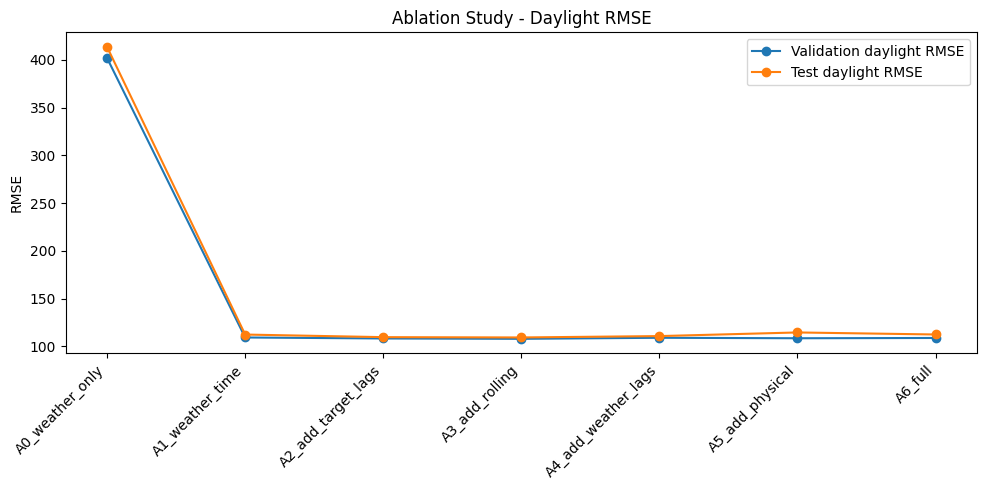

In [9]:
# ============================================================
# 8. Ablation study
# ============================================================

ablation_target = PRIMARY_TARGET

ablation_sets = {
    "A0_weather_only": keep_existing(["Temperature", "Humidity", "Pressure", "Wind_Speed", "Wind_Direction", "Solar_Radiation_Wh_m2"]),
    "A1_weather_time": list(dict.fromkeys(weather_current + time_cyclic)),
    "A2_add_target_lags": list(dict.fromkeys(weather_current + time_cyclic + target_lags_core)),
    "A3_add_rolling": list(dict.fromkeys(weather_current + time_cyclic + target_lags_core + rolling_core)),
    "A4_add_weather_lags": list(dict.fromkeys(weather_current + time_cyclic + target_lags_core + rolling_core + weather_lags)),
    "A5_add_physical": list(dict.fromkeys(weather_current + time_cyclic + target_lags_core + rolling_core + weather_lags + physical_features)),
    "A6_full": full_features,
}

ablation_results = []

for name, cols in ablation_sets.items():
    if len(cols) == 0:
        continue

    print(f"\nAblation {name}: {len(cols)} features")
    model = HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.05,
        max_iter=600,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=RANDOM_STATE
    )

    try:
        row, fitted, val_pred, test_pred = fit_predict_model(
            model_name=f"HGBR_{name}",
            model=model,
            features=cols,
            target=ablation_target,
            feature_set_name=name,
            max_train_rows=None,
        )
        ablation_results.append(row)
        print(f"Val daylight RMSE: {row['val_daylight_RMSE']:.4f} | Test daylight RMSE: {row['test_daylight_RMSE']:.4f}")
    except Exception as e:
        print("FAILED:", name, repr(e))

ablation_df = pd.DataFrame(ablation_results).sort_values("val_daylight_RMSE").reset_index(drop=True)

display(ablation_df[[
    "target", "model", "feature_set", "n_features",
    "val_all_RMSE", "val_daylight_RMSE", "val_all_R2", "val_daylight_R2",
    "test_all_RMSE", "test_daylight_RMSE", "test_all_R2", "test_daylight_R2"
]])

# Plot ablation
plt.figure(figsize=(10, 5))
plot_df = ablation_df.sort_values("n_features")
plt.plot(plot_df["feature_set"], plot_df["val_daylight_RMSE"], marker="o", label="Validation daylight RMSE")
plt.plot(plot_df["feature_set"], plot_df["test_daylight_RMSE"], marker="o", label="Test daylight RMSE")
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Ablation Study - Daylight RMSE")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_daylight_rmse.png", dpi=160)
plt.show()


## 9. Chọn mô hình tốt nhất theo validation daylight RMSE

Sau khi chọn, notebook vẽ biểu đồ dự báo trên test set.

Best model by validation daylight RMSE:


,target,model,feature_set,n_features,train_rows_used,train_time_sec,artifact_key,val_all_MAE,val_all_MSE,val_all_RMSE,...,test_daylight_MAE,test_daylight_MSE,test_daylight_RMSE,test_daylight_MaxError,test_daylight_R2,test_daylight_NRMSE_range,test_daylight_NRMSE_mean,test_all_skill_vs_persistence,test_daylight_skill_vs_persistence,params
20,target_1h,HGBR_tuned_4,full,67,17208,2.703237,target_1h__HGBR_tuned_4__full,33.610788,6058.368897,77.835525,...,65.349912,12564.37184,112.090909,886.005786,0.988292,0.029742,0.070383,0.780367,0.778429,"{""learning_rate"": 0.05, ""max_iter"": 700, ""max_..."


Saved best model: c:\Users\nguye\Downloads\Big_Data\models_02\best_model_target_1h_HGBR_tuned_4.joblib


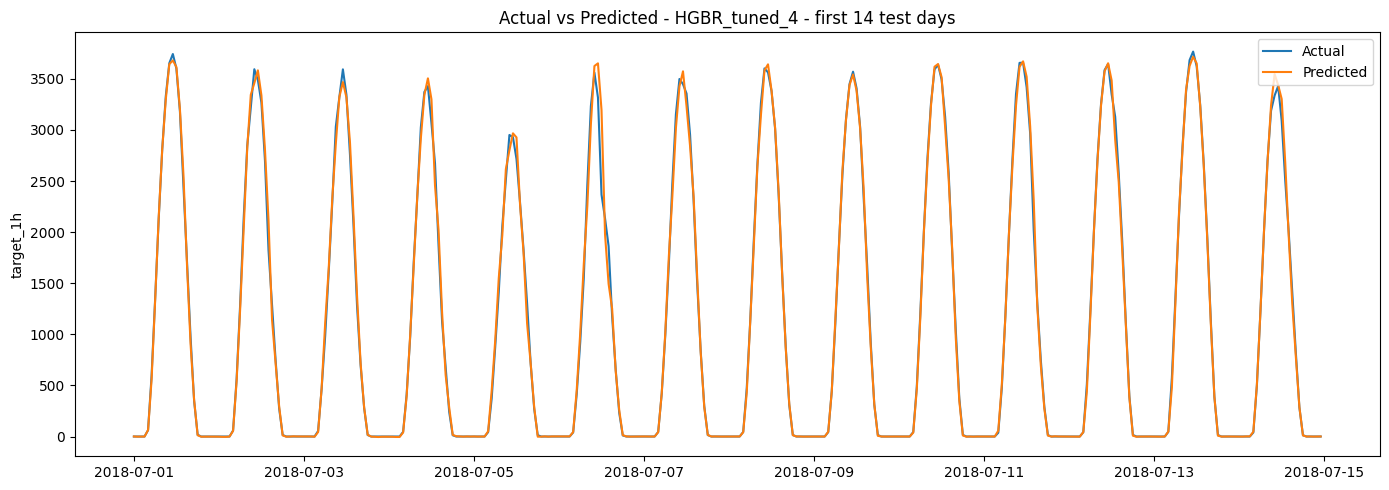

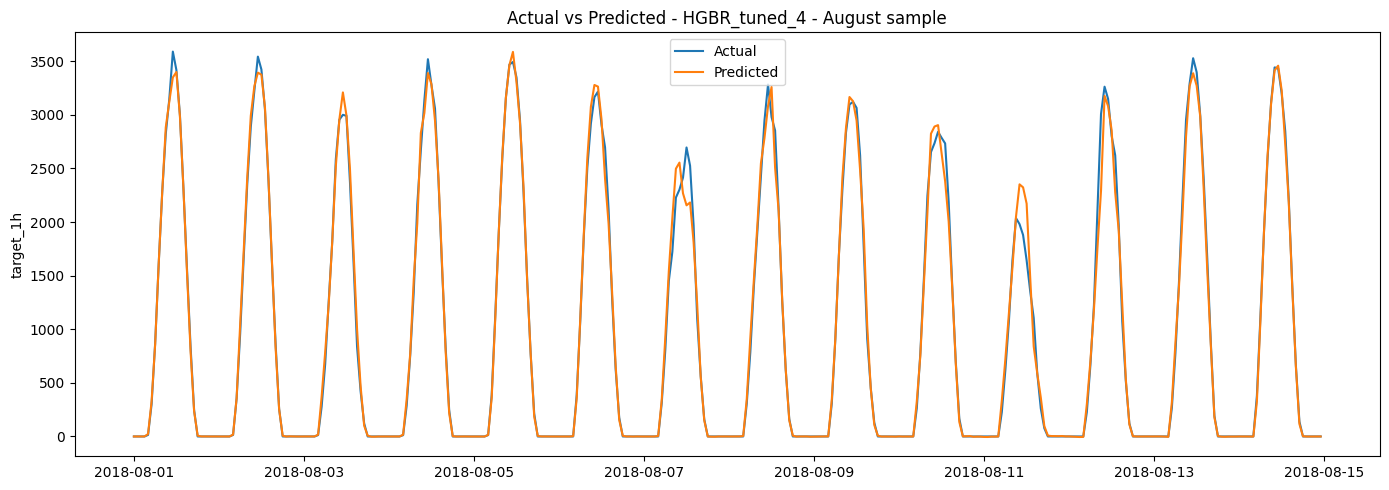

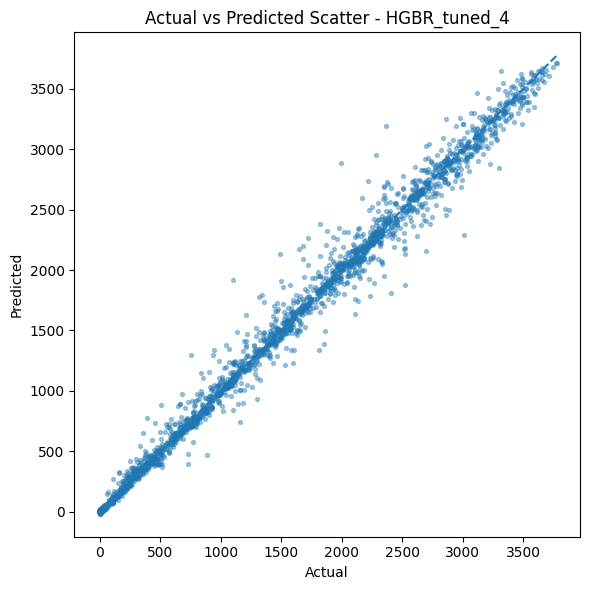

In [10]:
# ============================================================
# 9. Select best model and generate prediction plots
# ============================================================

# Gộp main + tuning + ablation để chọn model tốt nhất cho target_1h
candidate_tables = []
if "results_df" in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    candidate_tables.append(results_df)
if "tuning_df" in globals() and isinstance(tuning_df, pd.DataFrame) and not tuning_df.empty:
    candidate_tables.append(tuning_df)
if "ablation_df" in globals() and isinstance(ablation_df, pd.DataFrame) and not ablation_df.empty:
    candidate_tables.append(ablation_df)

all_candidates = pd.concat(candidate_tables, ignore_index=True)
candidate_primary = all_candidates[
    (all_candidates["target"] == PRIMARY_TARGET) &
    (~all_candidates["model"].isin(["Persistence", "SeasonalPersistence24h"]))
].copy()

best_row = candidate_primary.sort_values(["val_daylight_RMSE", "val_all_RMSE"]).iloc[0]
print("Best model by validation daylight RMSE:")
display(best_row.to_frame().T)

artifact_key = best_row.get("artifact_key", "")
if artifact_key not in trained_artifacts:
    raise KeyError(f"Không tìm thấy artifact_key trong trained_artifacts: {artifact_key}")

bundle = trained_artifacts[artifact_key]
best_model = bundle["model"]
best_features = bundle["features"]
best_target = bundle["target"]
best_name = best_row["model"]

# Chỉ lưu best model, không lưu toàn bộ model để tránh lộn xộn
best_model_path = MODEL_DIR / f"best_model_{best_target}_{best_name}.joblib"
joblib.dump({
    "model": best_model,
    "features": best_features,
    "target": best_target,
    "feature_set": best_row.get("feature_set", ""),
    "best_row": best_row.to_dict(),
}, best_model_path)
print("Saved best model:", best_model_path)

X_test = test_df[best_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y_test = test_df[best_target].astype(float)
test_pred = best_model.predict(X_test)

pred_test_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": test_pred,
    "residual": y_test.values - test_pred,
}, index=test_df.index)

# 14 ngày đầu của test
plt.figure(figsize=(14, 5))
sample = pred_test_df.iloc[:24*14]
plt.plot(sample.index, sample["y_true"], label="Actual")
plt.plot(sample.index, sample["y_pred"], label="Predicted")
plt.title(f"Actual vs Predicted - {best_name} - first 14 test days")
plt.ylabel(best_target)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "best_model_actual_vs_pred_first14days.png", dpi=160)
plt.show()

# Một đoạn mùa hè tùy ý trong test
plt.figure(figsize=(14, 5))
sample = pred_test_df.loc["2018-08-01":"2018-08-14"]
plt.plot(sample.index, sample["y_true"], label="Actual")
plt.plot(sample.index, sample["y_pred"], label="Predicted")
plt.title(f"Actual vs Predicted - {best_name} - August sample")
plt.ylabel(best_target)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "best_model_actual_vs_pred_august.png", dpi=160)
plt.show()

# Scatter
plt.figure(figsize=(6, 6))
plt.scatter(pred_test_df["y_true"], pred_test_df["y_pred"], s=8, alpha=0.4)
mn = min(pred_test_df["y_true"].min(), pred_test_df["y_pred"].min())
mx = max(pred_test_df["y_true"].max(), pred_test_df["y_pred"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted Scatter - {best_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "best_model_scatter.png", dpi=160)
plt.show()


## 10. Error analysis theo giờ và theo tháng

Phần này rất quan trọng cho báo cáo vì cho thấy mô hình sai nhiều vào khung giờ nào, mùa nào.

,group_value,MAE,RMSE,mean_actual,n,group_type
0,0,0.855801,1.496266,0.000000,183,hour_all
1,1,0.967807,1.682451,0.000000,183,hour_all
2,2,1.014892,1.736866,0.000000,183,hour_all
3,3,0.968995,1.630231,0.000000,183,hour_all
4,4,2.536388,3.881666,6.230754,183,hour_all
5,5,20.358570,32.786385,151.466754,183,hour_all
6,6,46.516972,64.815768,621.430230,183,hour_all
7,7,57.124471,88.219409,1300.178754,183,hour_all
8,8,56.117727,86.188712,1945.797639,183,hour_all
9,9,77.078770,130.534878,2445.598230,183,hour_all


,group_value,MAE,RMSE,mean_actual,n,group_type
0,7,37.715029,83.612631,1118.516952,744,month_all
1,8,45.993086,99.366769,980.366032,744,month_all
2,9,43.217577,95.252559,811.294800,720,month_all
3,10,35.704784,81.439449,741.437177,744,month_all
4,11,29.068709,70.867995,590.667250,720,month_all
5,12,10.306623,20.891683,580.170300,720,month_all


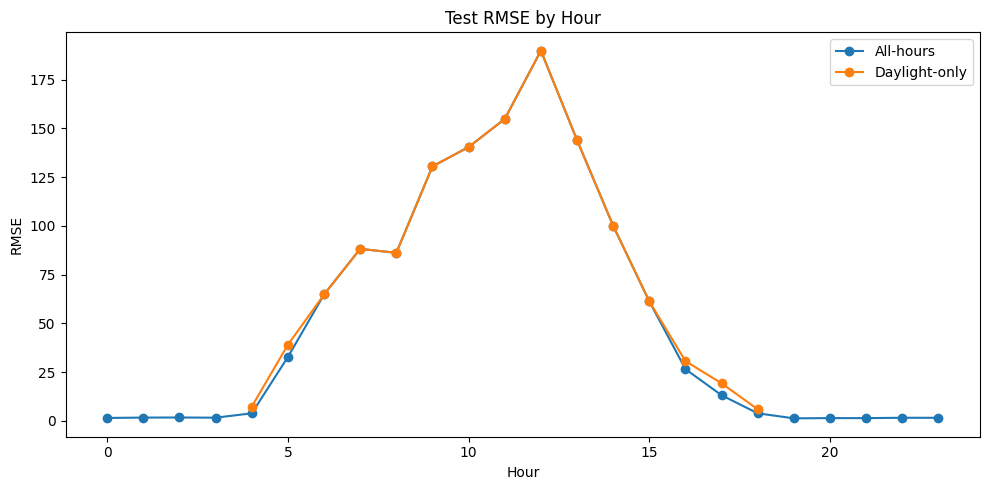

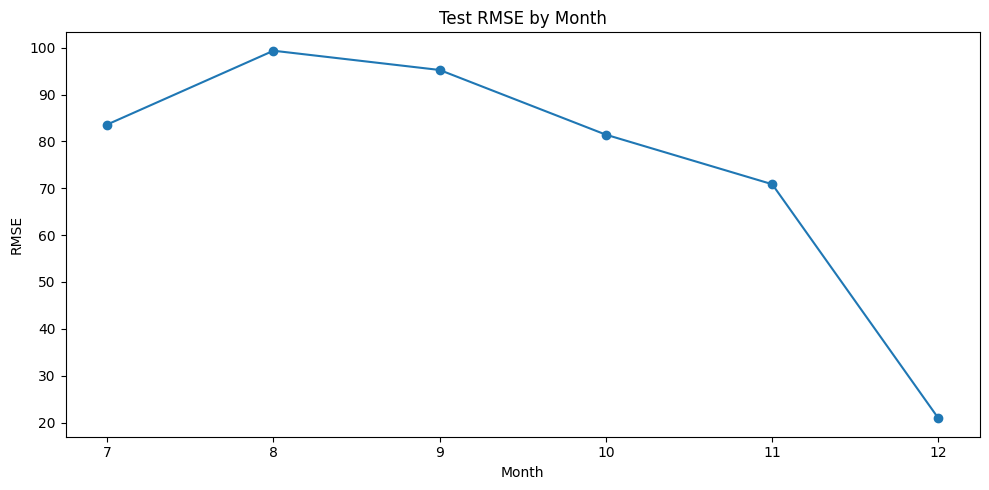

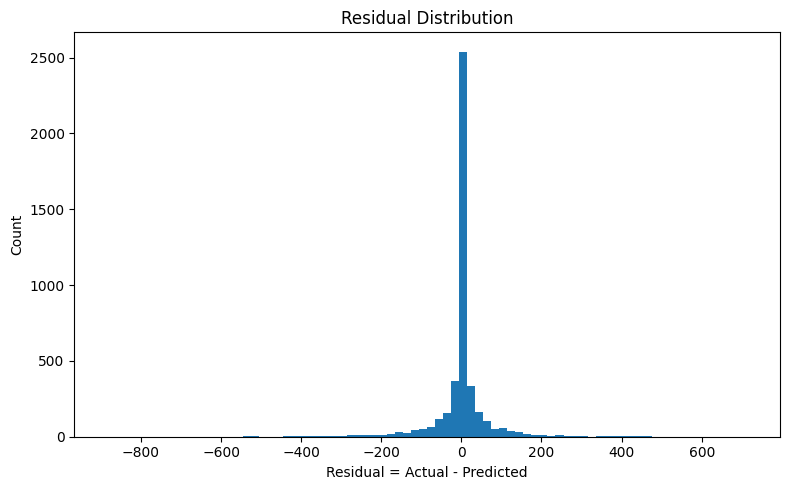

In [11]:
# ============================================================
# 10. Error analysis by hour and month
# ============================================================

err_df = pred_test_df.copy()
err_df["abs_error"] = err_df["residual"].abs()
err_df["sq_error"] = err_df["residual"] ** 2
err_df["hour"] = err_df.index.hour
err_df["month"] = err_df.index.month
err_df["daylight"] = err_df["y_true"] > 0

by_hour = err_df.groupby("hour").agg(
    MAE=("abs_error", "mean"),
    RMSE=("sq_error", lambda x: np.sqrt(np.mean(x))),
    mean_actual=("y_true", "mean"),
    n=("y_true", "size"),
).reset_index()
by_hour["group_type"] = "hour_all"
by_hour = by_hour.rename(columns={"hour": "group_value"})

by_hour_day = err_df[err_df["daylight"]].groupby("hour").agg(
    MAE=("abs_error", "mean"),
    RMSE=("sq_error", lambda x: np.sqrt(np.mean(x))),
    mean_actual=("y_true", "mean"),
    n=("y_true", "size"),
).reset_index()
by_hour_day["group_type"] = "hour_daylight"
by_hour_day = by_hour_day.rename(columns={"hour": "group_value"})

by_month = err_df.groupby("month").agg(
    MAE=("abs_error", "mean"),
    RMSE=("sq_error", lambda x: np.sqrt(np.mean(x))),
    mean_actual=("y_true", "mean"),
    n=("y_true", "size"),
).reset_index()
by_month["group_type"] = "month_all"
by_month = by_month.rename(columns={"month": "group_value"})

error_analysis_df = pd.concat([by_hour, by_hour_day, by_month], ignore_index=True)

display(by_hour)
display(by_month)

plt.figure(figsize=(10, 5))
plt.plot(by_hour["group_value"], by_hour["RMSE"], marker="o", label="All-hours")
if not by_hour_day.empty:
    plt.plot(by_hour_day["group_value"], by_hour_day["RMSE"], marker="o", label="Daylight-only")
plt.xlabel("Hour")
plt.ylabel("RMSE")
plt.title("Test RMSE by Hour")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "test_rmse_by_hour.png", dpi=160)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(by_month["group_value"], by_month["RMSE"], marker="o")
plt.xlabel("Month")
plt.ylabel("RMSE")
plt.title("Test RMSE by Month")
plt.tight_layout()
plt.savefig(FIG_DIR / "test_rmse_by_month.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(err_df["residual"], bins=80)
plt.xlabel("Residual = Actual - Predicted")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "residual_distribution.png", dpi=160)
plt.show()


## 11. Feature importance

Với tree-based model, ưu tiên dùng `feature_importances_` nếu model hỗ trợ.  
Nếu không có, dùng permutation importance trên một mẫu nhỏ của test set.

Computing permutation importance on sample: 1500


,feature,importance,importance_std
52,solar_elevation_approx_deg,874.087333,10.915461
62,sim_pv_dc_kWh_per_kWp,331.380563,8.859632
7,hour_sin,278.032534,8.206900
60,pvlib_clear_sky_index_current,177.031879,2.181324
4,Solar_Radiation_Wh_m2,109.272148,1.473622
24,Solar_Energy_kJ_m2_roll_std_3h,83.621197,1.621337
55,clear_sky_index_current,25.489851,1.444928
59,pvlib_clear_sky_ghi_Wh_m2,3.857066,0.345382
61,sim_cell_temperature_C,3.445577,0.710135
3,Humidity,2.436664,0.434481


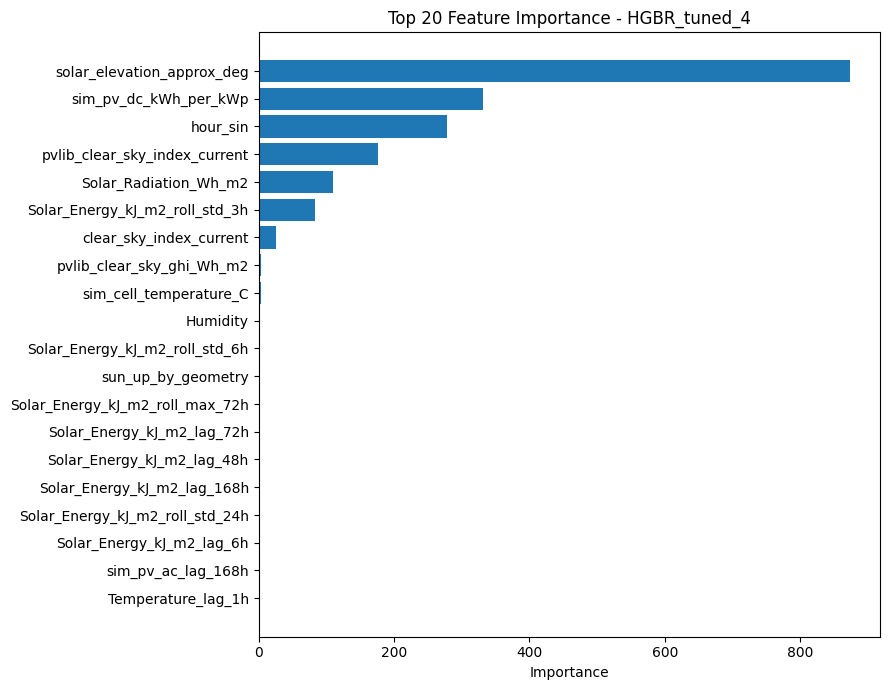

In [12]:
# ============================================================
# 11. Feature importance
# ============================================================

def get_inner_model(model):
    if isinstance(model, Pipeline):
        return model.steps[-1][1]
    return model

inner = get_inner_model(best_model)
importance_df = None

if hasattr(inner, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": best_features,
        "importance": inner.feature_importances_
    }).sort_values("importance", ascending=False)
else:
    # Permutation importance có thể chậm, dùng mẫu nhỏ
    sample_n = min(1500, len(X_test))
    X_sample = X_test.iloc[:sample_n]
    y_sample = y_test.iloc[:sample_n]

    print("Computing permutation importance on sample:", sample_n)
    perm = permutation_importance(
        best_model,
        X_sample,
        y_sample,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    importance_df = pd.DataFrame({
        "feature": best_features,
        "importance": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance", ascending=False)

display(importance_df.head(30))

plt.figure(figsize=(9, 7))
top_imp = importance_df.head(20).iloc[::-1]
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Importance")
plt.title(f"Top 20 Feature Importance - {best_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_top20.png", dpi=160)
plt.show()


## 12. Lưu kết quả cuối cùng cho báo cáo

Để thư mục sạch, notebook chỉ lưu các CSV quan trọng nhất:

- `02_results_all_models.csv`: toàn bộ kết quả main models + HGBR tuning + ablation.
- `02_summary_for_report.csv`: bảng rút gọn dùng đưa vào báo cáo.
- `02_ablation.csv`: bảng ablation study.
- `02_error_analysis.csv`: lỗi theo giờ/tháng.
- `02_feature_importance.csv`: độ quan trọng feature của best model.

Các biểu đồ được lưu trong `figures_02/`.  
Chỉ best model được lưu trong `models_02/`.


In [13]:
# ============================================================
# 12. Final summary tables
# ============================================================

# 1) All model results: main + tuning + ablation
all_results = all_candidates.copy()
all_results = all_results.sort_values(
    ["target", "val_daylight_RMSE", "val_all_RMSE"],
    ascending=[True, True, True]
).reset_index(drop=True)

all_results_path = OUT_DIR / "02_results_all_models.csv"
all_results.to_csv(all_results_path, index=False)

# 2) Summary table for report
summary_cols = [
    "target", "model", "feature_set", "n_features", "train_time_sec",
    "val_all_RMSE", "val_daylight_RMSE", "val_all_R2", "val_daylight_R2",
    "test_all_RMSE", "test_daylight_RMSE", "test_all_R2", "test_daylight_R2",
    "test_daylight_skill_vs_persistence"
]

summary = all_results[[c for c in summary_cols if c in all_results.columns]]
summary = summary.sort_values(["target", "val_daylight_RMSE", "val_all_RMSE"]).reset_index(drop=True)

summary_path = OUT_DIR / "02_summary_for_report.csv"
summary.to_csv(summary_path, index=False)

# 3) Ablation only
ablation_path = OUT_DIR / "02_ablation.csv"
ablation_df.to_csv(ablation_path, index=False)

# 4) Error analysis
error_path = OUT_DIR / "02_error_analysis.csv"
error_analysis_df.to_csv(error_path, index=False)

# 5) Feature importance
importance_path = OUT_DIR / "02_feature_importance.csv"
importance_df.to_csv(importance_path, index=False)

print("Saved essential CSV files:")
for p in [all_results_path, summary_path, ablation_path, error_path, importance_path]:
    print("-", p)

print("\nSaved best model:")
print("-", best_model_path)

print("\nSaved figures:")
for p in sorted(FIG_DIR.glob("*.png")):
    print("-", p)

display(summary.head(40))


Saved essential CSV files:
- c:\Users\nguye\Downloads\Big_Data\outputs_02\02_results_all_models.csv
- c:\Users\nguye\Downloads\Big_Data\outputs_02\02_summary_for_report.csv
- c:\Users\nguye\Downloads\Big_Data\outputs_02\02_ablation.csv
- c:\Users\nguye\Downloads\Big_Data\outputs_02\02_error_analysis.csv
- c:\Users\nguye\Downloads\Big_Data\outputs_02\02_feature_importance.csv

Saved best model:
- c:\Users\nguye\Downloads\Big_Data\models_02\best_model_target_1h_HGBR_tuned_4.joblib

Saved figures:
- c:\Users\nguye\Downloads\Big_Data\figures_02\ablation_daylight_rmse.png
- c:\Users\nguye\Downloads\Big_Data\figures_02\best_model_actual_vs_pred_august.png
- c:\Users\nguye\Downloads\Big_Data\figures_02\best_model_actual_vs_pred_first14days.png
- c:\Users\nguye\Downloads\Big_Data\figures_02\best_model_scatter.png
- c:\Users\nguye\Downloads\Big_Data\figures_02\feature_importance_top20.png
- c:\Users\nguye\Downloads\Big_Data\figures_02\residual_distribution.png
- c:\Users\nguye\Downloads\Big_Dat

,target,model,feature_set,n_features,train_time_sec,val_all_RMSE,val_daylight_RMSE,val_all_R2,val_daylight_R2,test_all_RMSE,test_daylight_RMSE,test_all_R2,test_daylight_R2,test_daylight_skill_vs_persistence
0,target_1h,HGBR_tuned_4,full,67,2.703237,77.835525,106.877493,0.996028,0.991660,79.766294,112.090909,0.994595,0.988292,0.778429
1,target_1h,HGBR_tuned_5,full,67,3.356850,78.001404,107.113211,0.996011,0.991624,79.855411,112.213848,0.994583,0.988266,0.778186
2,target_1h,HGBR_tuned_3,full,67,1.620996,78.499531,107.757400,0.995960,0.991522,80.186327,112.638459,0.994538,0.988177,0.777347
3,target_1h,RandomForest,full,67,8.191509,78.532821,107.880108,0.995957,0.991503,79.341053,111.520784,0.994652,0.988411,0.779556
4,target_1h,HGBR_A3_add_rolling,A3_add_rolling,29,1.434159,78.645642,107.906169,0.995945,0.991499,77.832525,109.336033,0.994854,0.988860,0.783875
5,target_1h,HGBR_tuned_1,full,67,1.409984,78.841497,108.233504,0.995925,0.991447,79.940326,112.309470,0.994571,0.988246,0.777997
6,target_1h,HGBR_A2_add_target_lags,A2_add_target_lags,22,0.606499,78.887699,108.276437,0.995920,0.991441,78.066562,109.655274,0.994823,0.988795,0.783244
7,target_1h,XGBoost,full,67,2.129589,78.917411,108.355553,0.995917,0.991428,77.695421,109.122720,0.994872,0.988904,0.784297
8,target_1h,HGBR_A5_add_physical,A5_add_physical,56,0.669189,79.042875,108.505444,0.995904,0.991404,81.565736,114.571660,0.994348,0.987768,0.773526
9,target_1h,HistGradientBoosting,full,67,4.032979,79.247837,108.797907,0.995883,0.991358,80.030169,112.443331,0.994559,0.988218,0.777733
